In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/himan/OneDrive/Documents/KaggleV2-May-2016.csv")

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace('-', '_')

In [4]:
# Convert dates
df['scheduledday'] = pd.to_datetime(df['scheduledday'])
df['appointmentday'] = pd.to_datetime(df['appointmentday'])

In [5]:
# Create wait time (MOST IMPORTANT FEATURE)
df['wait_time'] = (df['appointmentday'] - df['scheduledday']).dt.days


In [6]:
# Convert target variable
df['no_show'] = df['no_show'].map({'Yes': 1, 'No': 0})

df.head()

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no_show,wait_time
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,-1
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,-1
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,-1
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,-1
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,-1


In [7]:
df.isnull().sum()
df['wait_time'].describe()
df[df['wait_time'] < 0]

,patientid,appointmentid,gender,scheduledday,appointmentday,age,neighbourhood,scholarship,hipertension,diabetes,alcoholism,handcap,sms_received,no_show,wait_time
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,0,-1
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,0,-1
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,0,-1
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,0,-1
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,0,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110511,8.235996e+11,5786742,F,2016-06-08 08:50:20+00:00,2016-06-08 00:00:00+00:00,14,MARIA ORTIZ,0,0,0,0,0,0,0,-1
110512,9.876246e+13,5786368,F,2016-06-08 08:20:01+00:00,2016-06-08 00:00:00+00:00,41,MARIA ORTIZ,0,0,0,0,0,0,0,-1
110513,8.674778e+13,5785964,M,2016-06-08 07:52:55+00:00,2016-06-08 00:00:00+00:00,2,ANTÔNIO HONÓRIO,0,0,0,0,0,0,0,-1
110514,2.695685e+12,5786567,F,2016-06-08 08:35:31+00:00,2016-06-08 00:00:00+00:00,58,MARIA ORTIZ,0,0,0,0,0,0,0,-1


In [8]:
df = df[df['wait_time'] >= 0]

In [9]:
df['no_show'].mean()

np.float64(0.285190177740102)

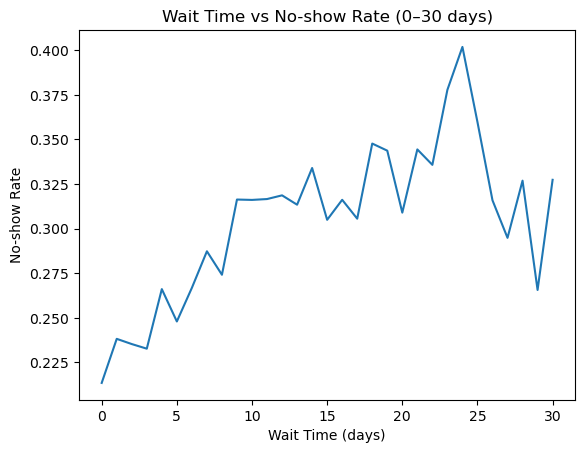

In [10]:
wait_analysis = df.groupby('wait_time')['no_show'].mean().reset_index()

# Filter realistic range (important)
wait_analysis = wait_analysis[wait_analysis['wait_time'] <= 30]

import matplotlib.pyplot as plt

plt.plot(wait_analysis['wait_time'], wait_analysis['no_show'])
plt.title("Wait Time vs No-show Rate (0–30 days)")
plt.xlabel("Wait Time (days)")
plt.ylabel("No-show Rate")
plt.show()

In [11]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 35, 60, 100],
    labels=['Child', 'Young', 'Adult', 'Senior']
)

age_analysis = df.groupby('age_group')['no_show'].mean()
age_analysis

C:\Users\himan\AppData\Local\Temp\ipykernel_11188\1819111777.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = df.groupby('age_group')['no_show'].mean()


age_group
Child     0.332059
Young     0.342251
Adult     0.267100
Senior    0.204480
Name: no_show, dtype: float64

In [12]:
print("""
Interpretation:
Younger patients (below 35) exhibit significantly higher no-show rates compared to older groups. 
This suggests behavioral patterns such as lower perceived urgency or weaker adherence to schedules, 
highlighting the need for targeted interventions for this segment.
""")


Interpretation:
Younger patients (below 35) exhibit significantly higher no-show rates compared to older groups. 
This suggests behavioral patterns such as lower perceived urgency or weaker adherence to schedules, 
highlighting the need for targeted interventions for this segment.



In [13]:
df.groupby('sms_received')['no_show'].mean()

sms_received
0    0.294377
1    0.275745
Name: no_show, dtype: float64

In [14]:
print("""
Interpretation:
SMS reminders alone do not significantly reduce no-show rates. 
This suggests that operational factors like scheduling delays may have a stronger impact than reminders.
""")


Interpretation:
SMS reminders alone do not significantly reduce no-show rates. 
This suggests that operational factors like scheduling delays may have a stronger impact than reminders.



In [15]:
features = ['age', 'wait_time', 'sms_received']
X = df[features]
y = df['no_show']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7150500277932185
              precision    recall  f1-score   support

           0       0.72      1.00      0.83     10301
           1       0.25      0.00      0.00      4091

    accuracy                           0.72     14392
   macro avg       0.48      0.50      0.42     14392
weighted avg       0.58      0.72      0.60     14392



In [32]:
print("""
Interpretation:
The model helps identify high-risk patients based on wait time, age, and reminder status, enabling hospitals to 
proactively intervene and reduce missed appointments.
""")


Interpretation:
The model helps identify high-risk patients based on wait time, age, and reminder status, enabling hospitals to 
proactively intervene and reduce missed appointments.



In [33]:
df['high_wait_flag'] = df['wait_time'].apply(lambda x: 1 if x > 3 else 0)

In [34]:
features = ['age', 'wait_time', 'sms_received', 'high_wait_flag']

In [37]:
print("""
Interpretation:
By identifying high-risk patients in advance, hospitals can optimize scheduling, reduce idle time, and improve 
operational efficiency.
""")


Interpretation:
By identifying high-risk patients in advance, hospitals can optimize scheduling, reduce idle time, and improve 
operational efficiency.



In [19]:
df.to_csv("C:/Users/himan/OneDrive/Desktop/cleaned_healthcare_data.csv", index=False)